In [1]:
import os
import re
import pandas as pd
import seaborn as sns
import numpy as np
from pyteomics import mzml
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

# Input data

In [ ]:
result_path = '' # add path to folder with FragPipe res
raw_dir_path = '' # add path to folder with raw files (mzML format)
annotation_path = f'{result_path}/experiment_annotation.tsv'

# Reading and prepare files

In [3]:
raw_files = [i for i in os.listdir(raw_dir_path) if i.endswith('.mzML')]

annotation_df = pd.read_csv(annotation_path, sep='\t')
experiments_path = [f'{result_path}/{i}' for i in annotation_df['sample_name']]

target_files = ['psm.tsv', 'peptide.tsv', 'protein.tsv']
sample_file_df = annotation_df[['file', 'sample_name']].copy()
sample_file_df['file'] = sample_file_df['file'].str.split('/').str[-1].str.split('.').str[0]

### Helper functions

In [4]:
def load_experiment(experiment_path: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
       '''
       Load FragPipe output tables (psm.tsv, peptide.tsv, protein.tsv) for one experiment.
       '''
       psm_df = pd.read_csv(f'{experiment_path}/psm.tsv', sep='\t')
       pep_df = pd.read_csv(f'{experiment_path}/peptide.tsv', sep='\t')
       prot_df = pd.read_csv(f'{experiment_path}/protein.tsv', sep='\t')
       return psm_df, pep_df, prot_df

def is_tryptic_N(prev_aa: str):
       '''
       Check whether the N-terminus of the peptide is tryptic.

       For trypsin:
         - N-terminus is considered tryptic if the preceding residue is K/R
           or if the peptide starts at the protein N-terminus ('-')
       '''
       return prev_aa in ("K", "R", '-')

def is_tryptic_C(seq, next_aa):
       '''
       Check whether the C-terminus of the peptide is tryptic.

       For trypsin:
       - C-terminus is tryptic if the last amino acid is K/R and
         the next residue is not P.
       - If next_aa is '-', the peptide ends at the protein C-terminus,
         which is considered tryptic.
       '''
       if next_aa != "-":
              return (seq[-1] in ("K", "R")) and (next_aa != "P")
       return True

def has_missed_cleavage(seq):
       '''
       Check whether a peptide has at least one potential missed cleavage
       for trypsin.

       A missed cleavage is defined as an internal K/R that is not followed by P.
       '''
       for aa, next_aa in zip(seq[:-1], seq[1:]):
              if aa in ('K', 'R') and next_aa != 'P':
                     return True
       return False

def classify_enzymatic_specificity(row):
       '''
       Classify a peptide based on enzymatic specificity (trypsin, N/C-termini only).

       Categories
       ----------
       - 'tryptic'       : both N- and C-termini are tryptic
       - 'semi-tryptic'  : exactly one terminus is tryptic or at least one missed cleavege 
       - 'non-tryptic'   : neither terminus is tryptic
       '''
       seq = row['Peptide']
       prev_aa = row['Prev AA']
       next_aa = row['Next AA']
       
       tN = is_tryptic_N(prev_aa)
       tC = is_tryptic_C(seq, next_aa)
       mc = has_missed_cleavage(seq)

       if (not tN) and (not tC):
              return "non-tryptic"
       
       if tN and tC:
              if mc:                             # comment this and
                     return 'semi-tryptic'       # this lines to remove miss cleavage in semi-tryptic indtication
              return 'tryptic'

       if tN or tC:
                  return 'semi-tryptic'

def make_grid_for_ms(n, cols=2, figsize_per_row=5):
    ''' 
    Makes plots grid
    '''
    rows = int(np.ceil(n / cols))
    fig, axs = plt.subplots(rows, cols, figsize=(16, figsize_per_row * rows))
    axs = np.array(axs).flatten()
    return fig, axs

def make_grid_for_qc(rows, cols=2, figsize_per_row=5):
    ''' 
    Makes plots grid
    '''
    fig, axs = plt.subplots(rows, cols, figsize=(16, figsize_per_row * rows))
    axs = np.array(axs) #.flatten()
    return fig, axs

# MS1/MS2 counting

In [5]:
rows = []

for mzMl in raw_files:
    mzMl_file = f'{raw_dir_path}/{mzMl}'
    ms1 = 0
    ms2 = 0
    with mzml.MzML(mzMl_file) as reader:
        for spectrum in reader:
            level = spectrum.get("ms level")
            if level == 1:
                ms1 += 1
            elif level == 2:
                ms2 += 1
    
    rows.append({
        "file": mzMl,
        "MS1": ms1,
        "MS2": ms2,
        "total": ms1 + ms2
    })

ms1ms2_df = pd.DataFrame(rows)

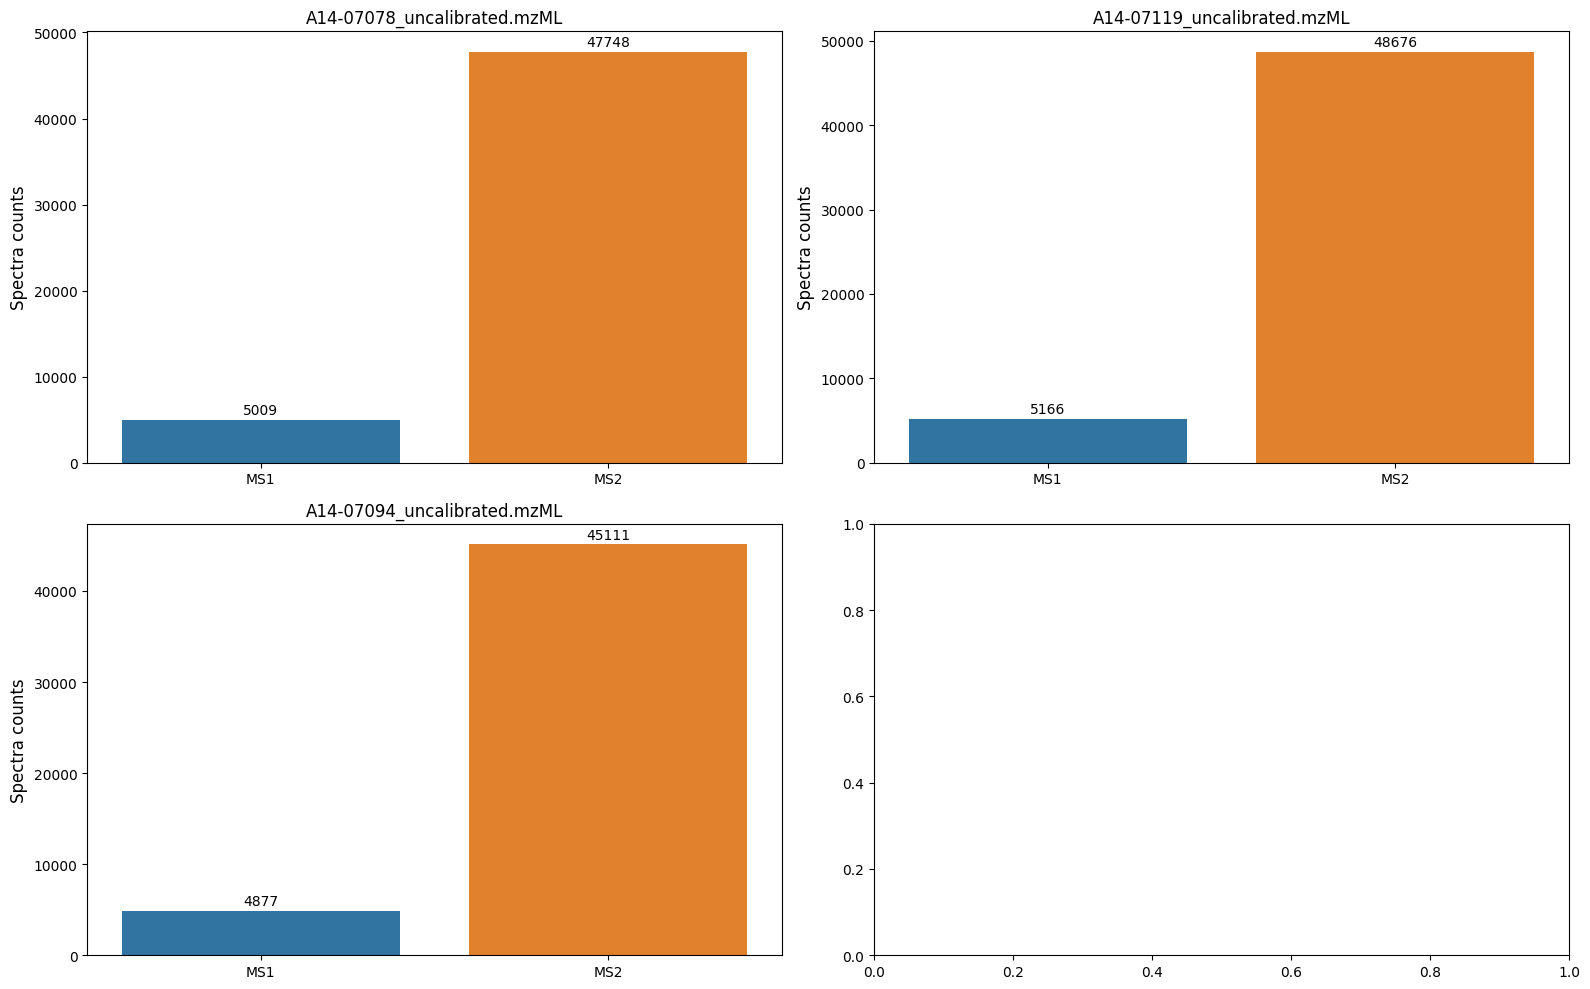

In [6]:
fig1, axs1 = make_grid_for_ms(ms1ms2_df['file'].shape[0], cols=2, figsize_per_row=5)

for i, exp in enumerate(ms1ms2_df['file']):
   ax = axs1[i]
   df_exp = ms1ms2_df[ms1ms2_df["file"] == exp]
   to_bar = df_exp[['MS1', 'MS2']].melt()
   sns.barplot(data=to_bar, x='variable', y='value', ax=ax, hue='variable')
   ax.set_title(exp)
   ax.set_xlabel('', fontsize=12)
   ax.set_ylabel('Spectra counts', fontsize=12)

   for container in ax.containers:
      ax.bar_label(container, fmt='%.0f', padding=2)

fig1.tight_layout()


# Trypsinolysis QC

### Helper functions

In [7]:
def basic_counts(psm_df: pd.DataFrame, pep_df: pd.DataFrame, prot_df: pd.DataFrame) -> tuple[int, int, int]:
    ''' 
    Compute basic counts of PSMs, unique peptides and proteins.
    '''
    n_pep = pep_df['Peptide'].nunique()
    n_prot = prot_df['Protein'].nunique()
    n_psm = psm_df.shape[0]

    return n_psm, n_pep, n_prot

def cleavages_intensity_counts(psm_df: pd.DataFrame) -> tuple[float, float]:
    '''
    Compute the fraction of PSMs and cumulative intensity
    that comes from PSMs with at least one missed cleavage.
    '''
    total_len = len(psm_df)
    if total_len > 0:
        mc_psm_pct = psm_df[psm_df['Number of Missed Cleavages'] > 0].shape[0] / total_len * 100
    else:
        mc_psm_pct = 0

    total_intensity = psm_df['Intensity'].sum()
    if total_intensity > 0:
        mc_intensity_pct = psm_df[psm_df['Number of Missed Cleavages'] > 0]['Intensity'].sum() / total_intensity * 100
    else:
        mc_intensity_pct = 0
    return mc_psm_pct, mc_intensity_pct

def tryptic_counts(pep_df: pd.DataFrame) -> tuple[float, float, float]:
    '''
    Compute fractions of fully/semi/non-tryptic peptides.

    Classification is based solely on N- and C-termini (Prev AA, Next AA).
    '''
    uniq_pep = pep_df.drop_duplicates(subset=['Peptide']).copy()
    uniq_pep["tryptic"] = uniq_pep.apply(classify_enzymatic_specificity, axis=1)
    
    total = uniq_pep.shape[0]
    full_tryptic = (uniq_pep['tryptic'] == 'tryptic').sum()
    semi_tryptic = (uniq_pep['tryptic'] == 'semi-tryptic').sum()
    non_tryptic = (uniq_pep['tryptic'] == 'non-tryptic').sum()
    
    percent_semi = semi_tryptic / total * 100
    percent_full = full_tryptic / total * 100
    percent_non = non_tryptic / total * 100

    return percent_full, percent_semi, percent_non

def mc_distribution(psm: pd.DataFrame, max_mc_display: int = 3) -> tuple[pd.Series, pd.Series]:
    '''
    Build a distribution of the number of missed cleavages per PSM.

    Values above `max_mc_display` are grouped into a single bin '{max_mc_display}+'.
    '''
    mc = psm["Number of Missed Cleavages"].fillna(0).astype(int)
    counts = mc.value_counts().sort_index()

    dist = {}
    for k, v in counts.items():
        if k <= max_mc_display:
            dist[k] = v
        else:
            dist[f"{max_mc_display}+"] = dist.get(f"{max_mc_display}+", 0) + v

    dist = pd.Series(dist).sort_index()
    dist_pct = dist / dist.sum() * 100
    return dist, dist_pct

def plot_mc_distribution(mc_pct: pd.Series, sample_name: str, ax: Axes) -> None:
    '''
    Plot the percent distribution of missed cleavages per PSM as a bar chart.
    '''
    mc_pct.plot(kind="bar", ax=ax)
    ax.set_ylabel("% PSM")
    ax.set_xlabel("Missed cleavages")
    ax.set_title(f"Missed cleavages: {sample_name}")

def peptide_length_distribution(pep: pd.DataFrame) -> pd.Series:
    '''
    Compute peptide length (amino acid count) for each peptide entry.
    '''
    seq = pep["Peptide"].dropna().astype(str)
    lengths = seq.str.len()
    return lengths

def plot_peptide_length(lengths: pd.Series, sample_name: str, ax: Axes) -> None:
    '''
    Plot peptide length distribution as a histogram.
    Uses bins from 5 to 50 (inclusive) via range(5, 51).
    '''
    sns.histplot(lengths, ax=ax, bins=range(5, 51))
    ax.set_xlabel("Peptide length (aa)")
    ax.set_ylabel("Count")
    ax.set_title(f"Peptide length distribution: {sample_name}")

def mc_vs_length(psm: pd.DataFrame) -> pd.DataFrame:
    '''
    Prepare a dataframe relating missed cleavages to peptide length at the PSM level.
    '''
    df = psm[["Peptide", "Number of Missed Cleavages"]].dropna().copy()
    df["Peptide"] = df["Peptide"].astype(str)
    df["length"] = df["Peptide"].str.len()
    df["Number of Missed Cleavages"] = df["Number of Missed Cleavages"].astype(int)
    return df

def plot_mc_vs_length(df: pd.DataFrame, sample_name: str, ax: Axes) -> None:
    '''
    Plot the relationship between peptide length and number of missed cleavages.
    '''
    sns.scatterplot(data=df, y='Number of Missed Cleavages', x='length', alpha=0.2, ax=ax)
    ax.set_xlabel("Peptide length (aa)")
    ax.set_ylabel("Missed cleavages")
    ax.set_title(f"MC vs length: {sample_name}")

def charge_distribution(psm: pd.DataFrame) -> tuple[pd.Series, pd.Series]:
    '''
    Compute charge state distribution at the PSM level.
    '''
    ch = psm["Charge"].dropna().astype(int)
    counts = ch.value_counts().sort_index()
    pct = counts / counts.sum() * 100
    return counts, pct

def plot_charge_distribution(charge_pct: pd.Series, sample_name: str, ax: Axes) -> None:
    '''
    Plot charge state distribution (% PSM) as a bar chart.
    '''
    sns.barplot(data=charge_pct, ax=ax)
    ax.set_xlabel("Charge state")
    ax.set_ylabel("% PSM")
    ax.set_title(f"Charge distribution: {sample_name}")

def intensity_distribution(psm: pd.DataFrame) -> pd.Series:
    '''
    Compute log10-transformed PSM intensity distribution.
    '''
    I = psm["Intensity"].replace(0, np.nan).dropna()
    I_log = np.log10(I)
    return I_log

def plot_intensity_distribution(I_log: pd.Series, sample_name: str, ax: Axes) -> None:
    '''
    Plot log10-transformed PSM intensity distribution as a histogram.
    '''
    sns.histplot(data=I_log, bins=50, ax=ax)
    ax.set_xlabel("log10(Intensity)")
    ax.set_ylabel("Count")
    ax.set_title(f"Intensity distribution: {sample_name}")

def protein_dynamic_range(prot: pd.DataFrame) -> pd.Series:
    '''
    Compute log10-transformed protein intensity distribution (dynamic range).
    '''
    I = prot['Total Intensity'].replace(0, np.nan).dropna()
    I_log = np.log10(I)
    return I_log

def plot_protein_dynamic_range(I_log: pd.Series, sample_name: str, ax: Axes) -> None:
    '''
    Plot log10-transformed protein intensity distribution as a histogram.
    '''
    sns.histplot(data=I_log, bins=50, ax=ax)
    ax.set_xlabel("log10(Protein intensity)")
    ax.set_ylabel("Count")
    ax.set_title(f"Protein dynamic range: {sample_name}")



### QC

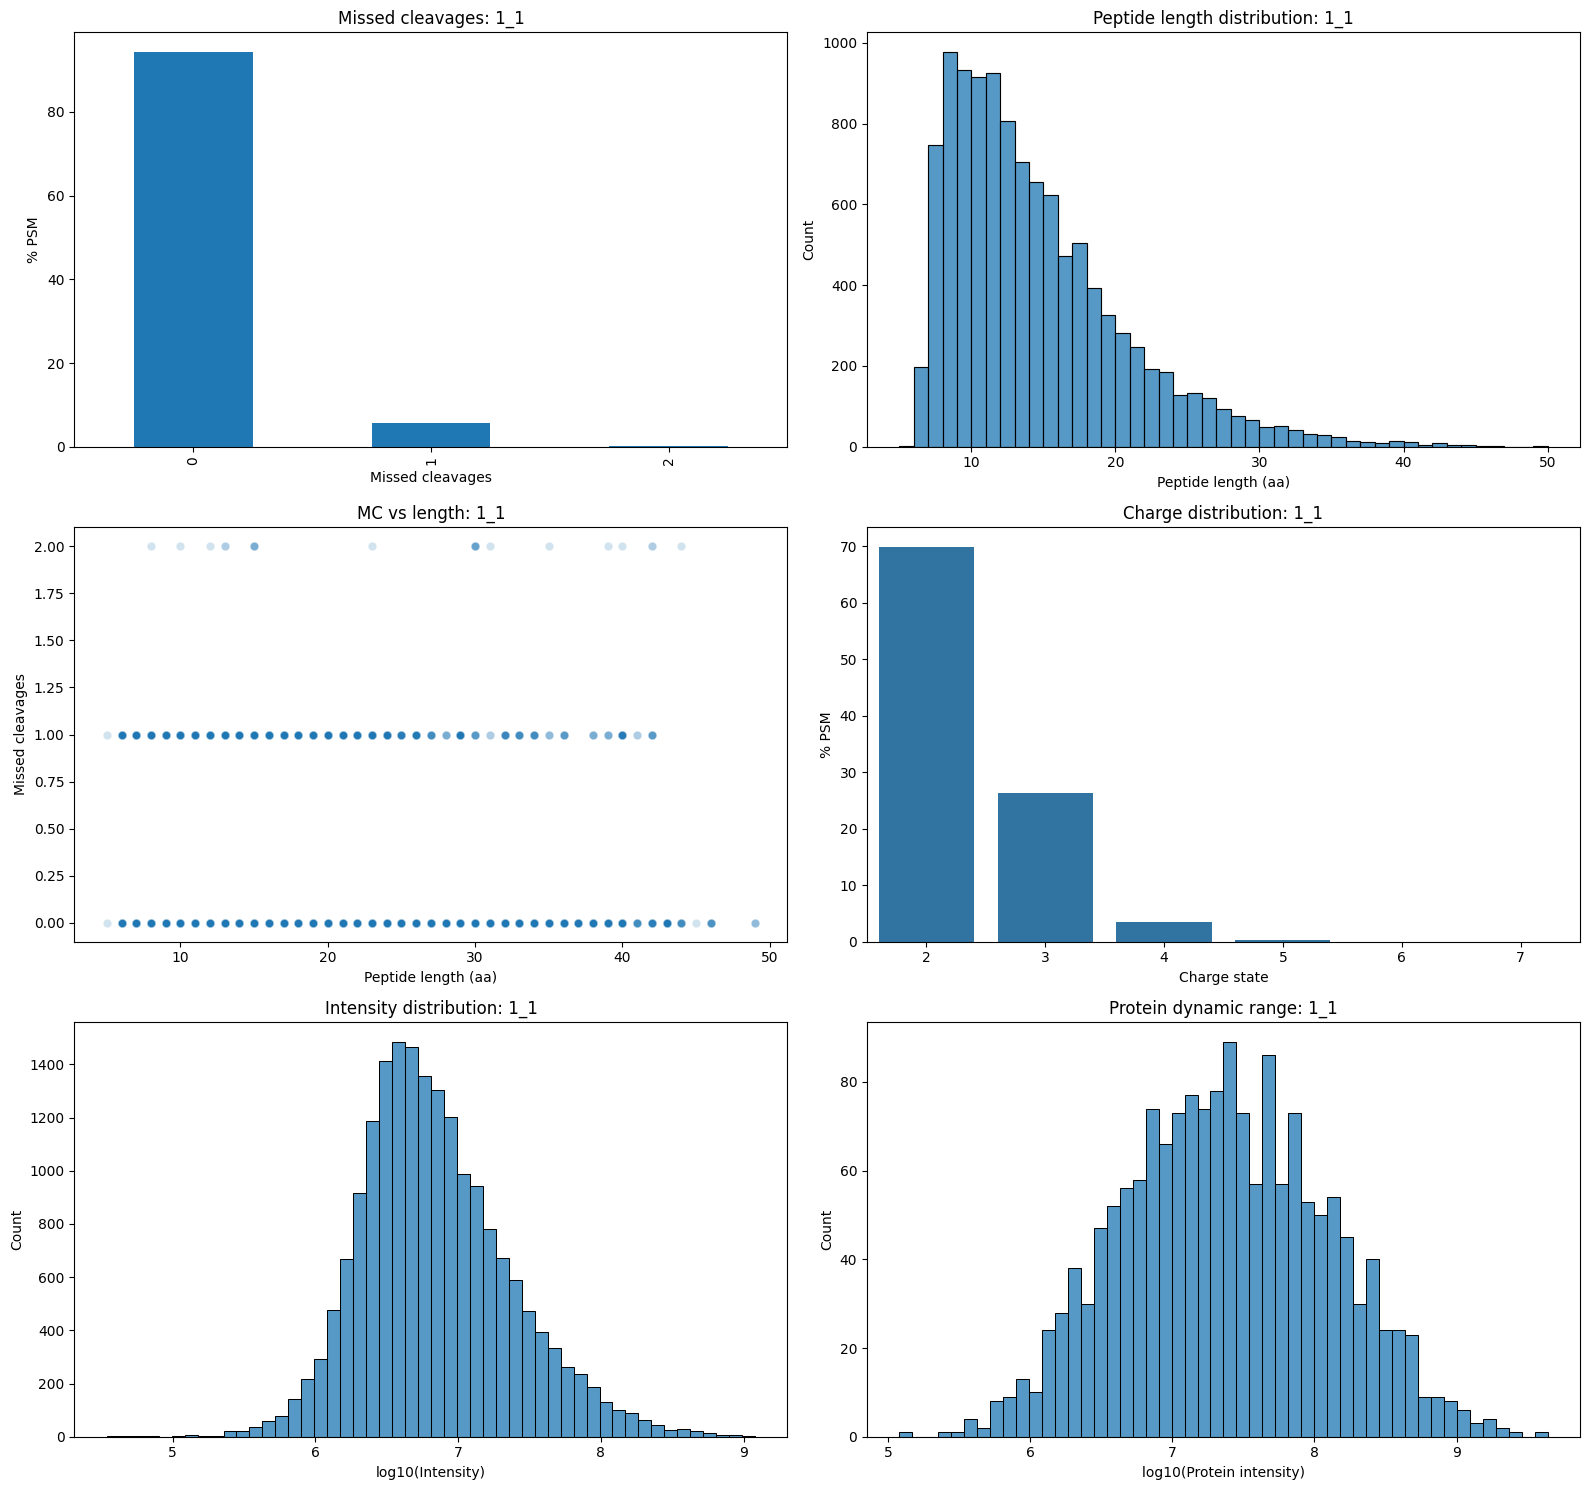

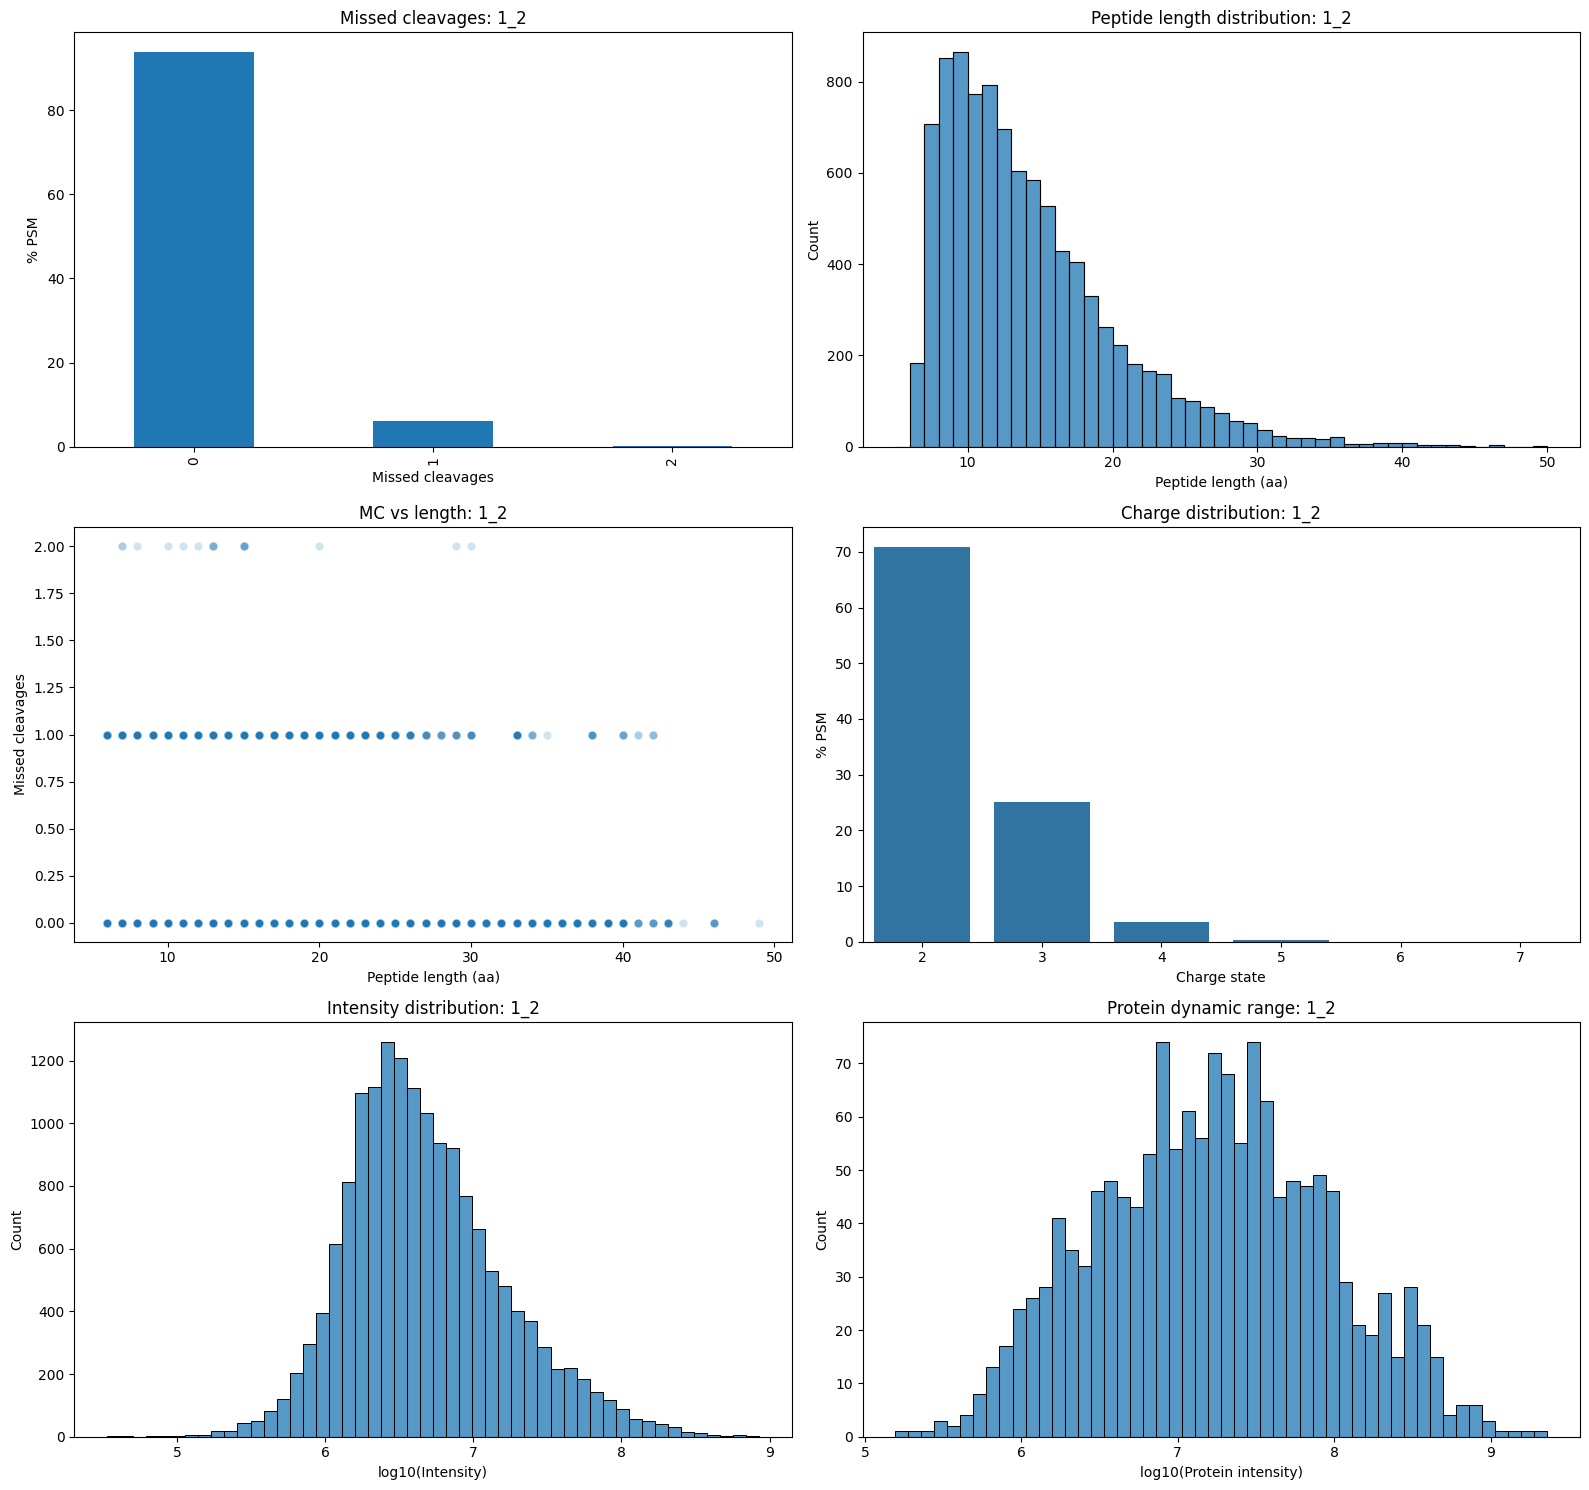

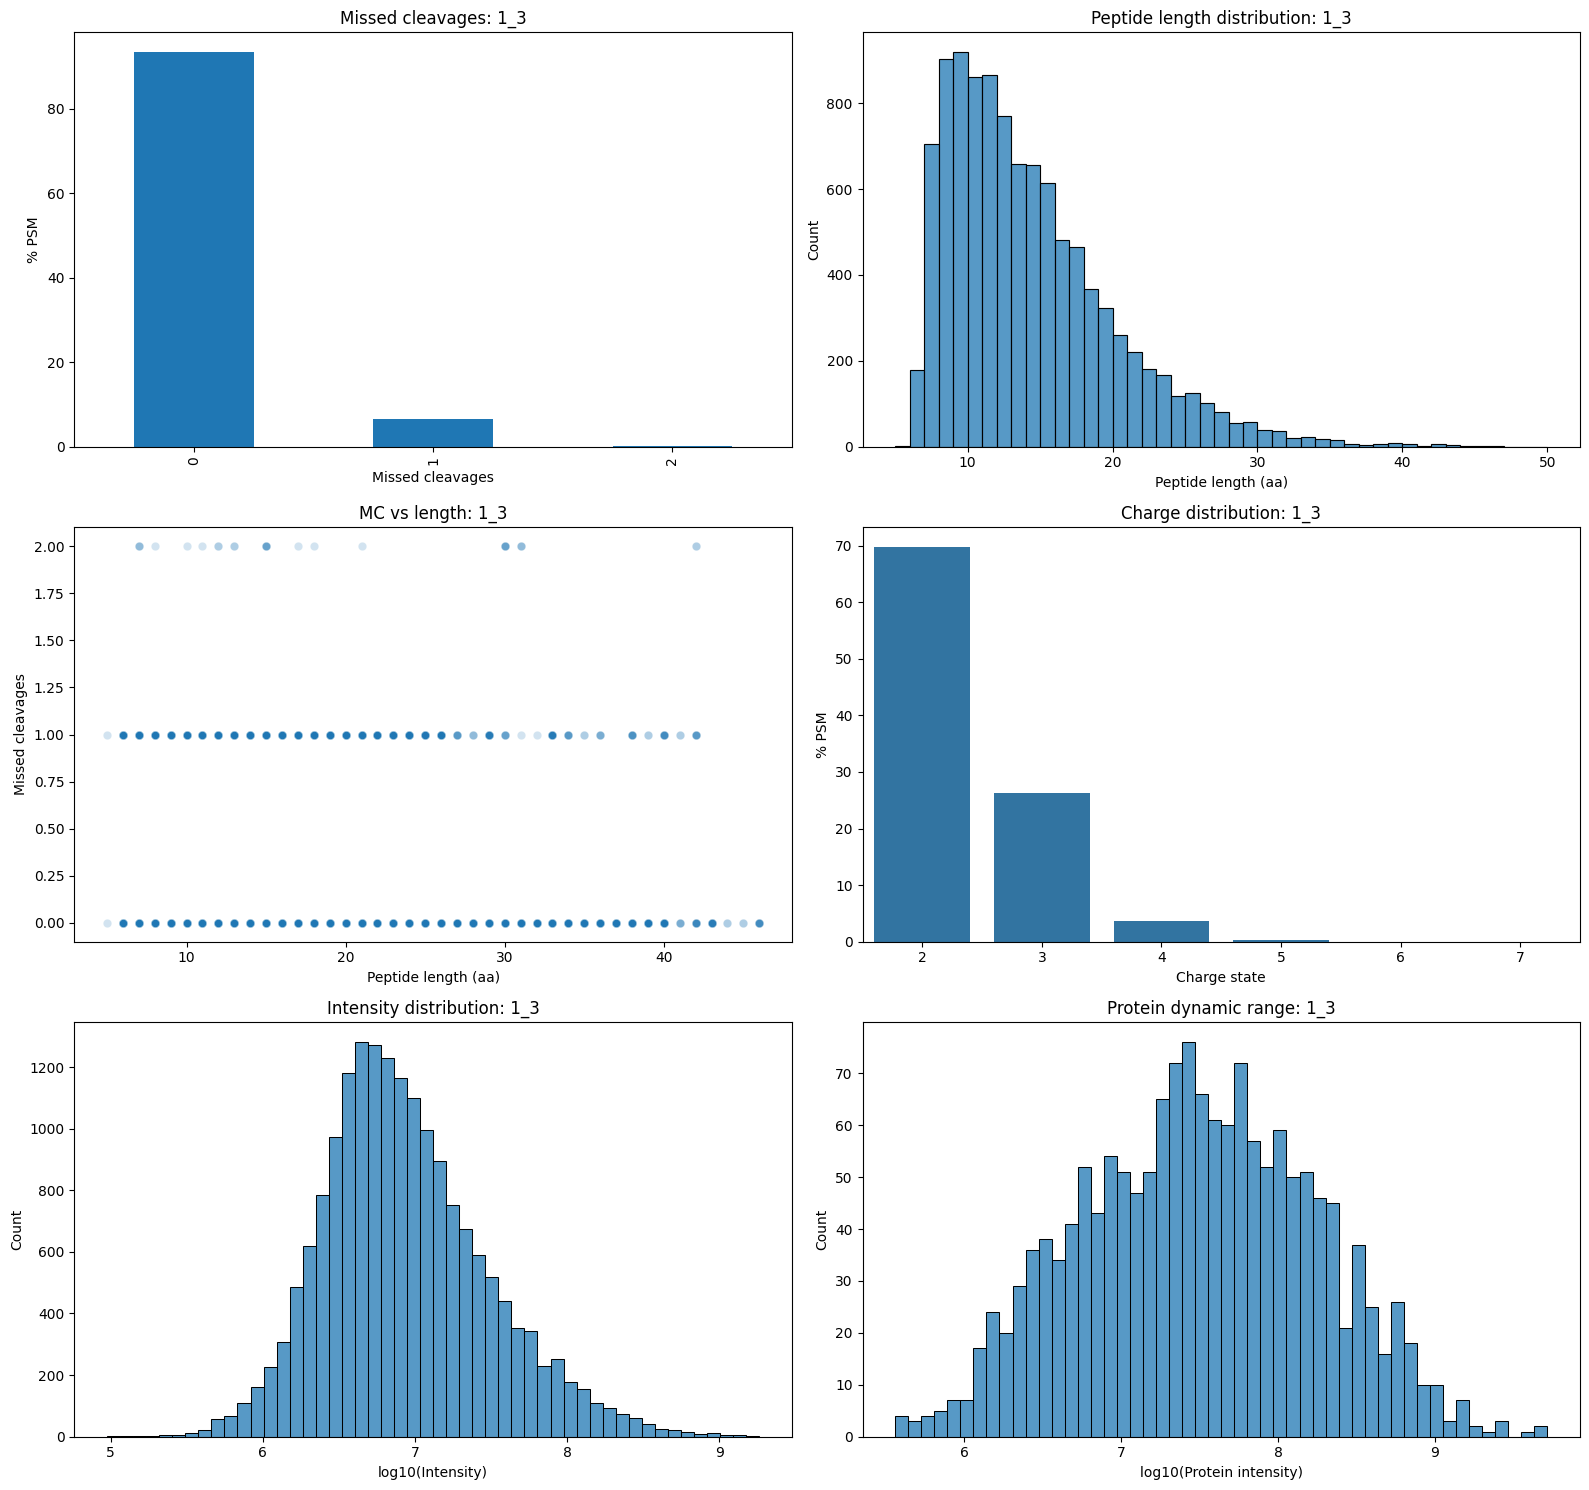

In [8]:
experiments_res = []
for i, experiment in enumerate(experiments_path):
    fig, axs = make_grid_for_qc(3, cols=2, figsize_per_row=5)
    experiment_name = os.path.split(experiment)[1]
    psm_df, pep_df, prot_df = load_experiment(experiment)

    n_psm, n_pep, n_prot = basic_counts(psm_df, pep_df, prot_df)
    semi_tryptic_missed_cleavages, semi_tryptic_intensity = cleavages_intensity_counts(psm_df)
    percent_full, percent_semi, percent_non = tryptic_counts(pep_df)

    mc_counts, mc_pct = mc_distribution(psm_df)
    pep_lengths = peptide_length_distribution(pep_df)
    mc_vc_len_df = mc_vs_length(psm_df)
    counts_charge, charge_df =  charge_distribution(psm_df)
    I_log_intensity = intensity_distribution(psm_df)
    protein_range = protein_dynamic_range(prot_df)

    plot_mc_distribution(mc_pct, experiment_name, axs[0][0])
    plot_peptide_length(pep_lengths, experiment_name, axs[0][1])
    plot_mc_vs_length(mc_vc_len_df, experiment_name, axs[1][0])
    plot_charge_distribution(charge_df, experiment_name, axs[1][1])
    plot_intensity_distribution(I_log_intensity,experiment_name, axs[2][0])
    plot_protein_dynamic_range(protein_range, experiment_name, axs[2][1])

    fig.tight_layout()

    row = {
        "sample": experiment_name,
        "PSM": n_psm,
        "Peptides": n_pep,
        "Proteins": n_prot,
        'percent_PSM_with_missed_cleavages': semi_tryptic_missed_cleavages,
        'percent_intensity_with_missed_cleavages': semi_tryptic_intensity,
        "MC>0_PSM_%": mc_pct.drop(0, errors="ignore").sum(),
        "Fully_tryptic_%": percent_full,
        "Semi_tryptic_%": percent_semi,
        "Non_tryptic_%": percent_non,
    }
    experiments_res.append(row)

experiments_res_df = pd.DataFrame(experiments_res)


# Merging data into single dataframe

In [9]:
col1_df2 = col1_df1 = sample_file_df.columns[0]
keys = sample_file_df[col1_df1].unique()
pattern = r'^(' + '|'.join(re.escape(k) for k in keys) + r')'

sample_file_df['_merge_key'] = sample_file_df[col1_df1]
ms1ms2_df['_merge_key'] = ms1ms2_df[col1_df2].str.extract(pattern, expand=False)
merged = ms1ms2_df.merge(sample_file_df, on='_merge_key', how='left', suffixes=('_left', '_right'))
merged = merged.merge(experiments_res_df, right_on='sample', left_on='sample_name', how='left')
merged = merged.drop(columns=['_merge_key', 'file_right', 'sample']).rename(columns={'file_left':'file_name'})

In [10]:
merged

,file_name,MS1,MS2,total,sample_name,PSM,Peptides,Proteins,percent_PSM_with_missed_cleavages,percent_intensity_with_missed_cleavages,MC>0_PSM_%,Fully_tryptic_%,Semi_tryptic_%,Non_tryptic_%
0,A14-07078_uncalibrated.mzML,5009,47748,52757,1_1,19289,11014,1663,5.707916,4.005677,5.707916,92.645724,7.354276,0.0
1,A14-07119_uncalibrated.mzML,5166,48676,53842,1_3,18437,10339,1592,6.606281,5.027312,6.606281,91.575588,8.424412,0.0
2,A14-07094_uncalibrated.mzML,4877,45111,49988,1_2,16435,9410,1497,6.194098,5.172663,6.194098,92.029756,7.970244,0.0
